# Data Mining Project : Outlier Detection with Data Depth

Loan Rottier, Maëlys Rapenne and Simon Simus

## Import packages

In [9]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from depth.model import DepthEucl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from depth.model.DepthEucl import DepthEucl


## Import and preprocess data

In [10]:
def load_data():
    data, meta = arff.loadarff("data\WBC_withoutdupl_v01.arff")
    df = pd.DataFrame(data)

    # cleaning byte strings to normal strings
    for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode("utf-8")

    print(df.describe())
    # print("Columns available :", df.columns.tolist())
    target_col = df.columns[-1]

    # transformr outlier into 0: normal, 1: anomaly
    y = np.where(df[target_col] == "yes", 1, 0).astype(int)
    cols_to_drop = ["outlier", "id"]
    X_raw = df.drop(columns=cols_to_drop).values.astype(float)

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)
    return X, y

X, y = load_data()


             att2        att3        att4        att5        att6        att7  \
count  223.000000  223.000000  223.000000  223.000000  223.000000  223.000000   
mean     3.506726    1.860987    1.982063    1.834081    2.443946    2.013453   
std      1.919248    1.672096    1.662962    1.609181    1.441110    2.163330   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      2.000000    1.000000    1.000000    1.000000    2.000000    1.000000   
50%      3.000000    1.000000    1.000000    1.000000    2.000000    1.000000   
75%      5.000000    2.000000    2.000000    2.000000    2.000000    2.000000   
max     10.000000   10.000000   10.000000   10.000000   10.000000   10.000000   

             att8        att9       att10          id  
count  223.000000  223.000000  223.000000  223.000000  
mean     2.408072    1.784753    1.139013  330.860987  
std      1.610586    1.857136    0.725006  209.394480  
min      1.000000    1.000000    1.000000    1

<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
C:\Users\simus\AppData\Local\Temp\ipykernel_20960\1334597612.py:2: SyntaxWarning: invalid escape sequence '\W'
  data, meta = arff.loadarff("data\WBC_withoutdupl_v01.arff")


## Part 1 : Depth functions with generated data :

Generate data in 2 dimensions. Only 2 dimensions because it's easier to visualize it

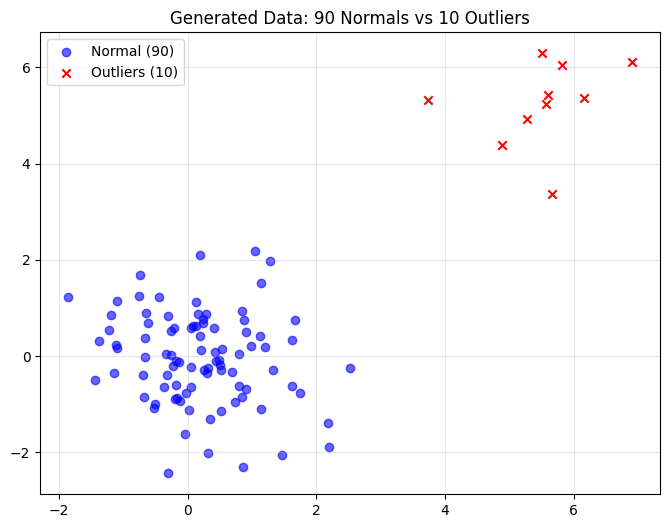

In [11]:
np.random.seed(1)

# Genrate 90 with N((0,0),I2) and 10 outliers with N((5,5),I2)

X_normal = np.random.normal(loc=0, scale=1, size=(90, 2))
y_normal = np.zeros(90) # Label 0 for normal

X_outliers = np.random.normal(loc=5, scale=1, size=(10, 2))
y_outliers = np.ones(10)  # Label 1 for outlier


X_generated = np.concatenate([X_normal, X_outliers])
y_generated = np.concatenate([y_normal, y_outliers])

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X_generated[y_generated==0, 0], X_generated[y_generated==0, 1], c='blue', label='Normal (90)', alpha=0.6)
plt.scatter(X_generated[y_generated==1, 0], X_generated[y_generated==1, 1], c='red', marker='x', label='Outliers (10)')
plt.title("Generated Data: 90 Normals vs 10 Outliers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Try 4 depths functions without train test split : projection depth, simplicial volume, simplicial and half space depth

x value is set to the loaded dataset


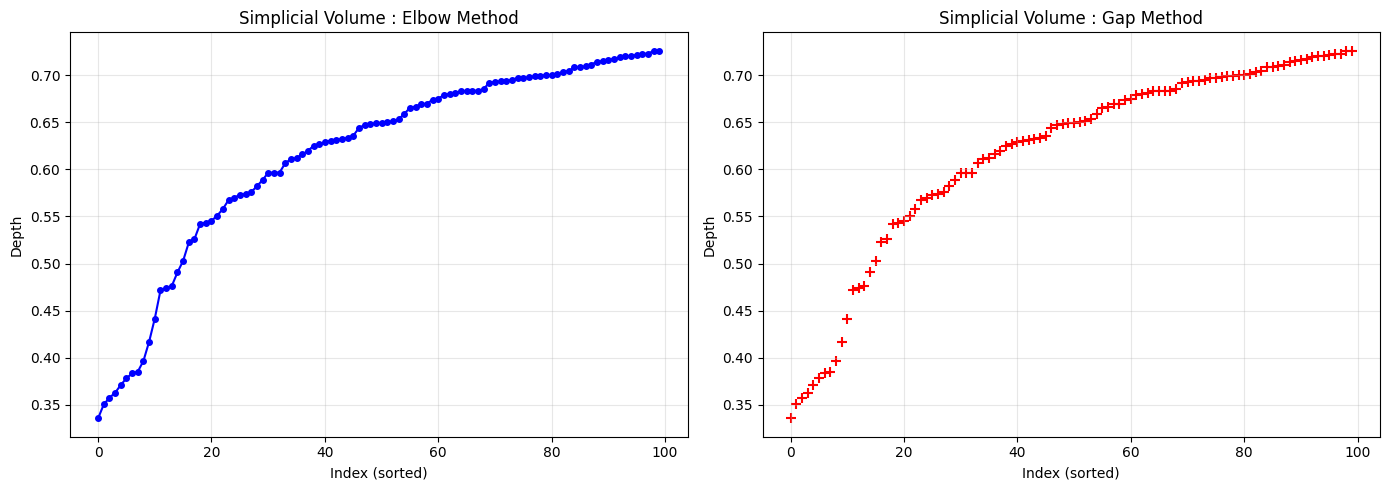

In [12]:
model=DepthEucl().load_dataset(X_generated)
depthX=model.simplicialVolume(X_generated)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores = model.simplicialVolume(evaluate_dataset=True, exact=True)

def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)
    
    index = np.arange(len(scores_sorted))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELBOW plot
    ax1.plot(index, scores_sorted, 'b-o', markersize=4)
    ax1.set_title("Simplicial Volume : Elbow Method")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)
    
    # GAP plot
    ax2.scatter(index, scores_sorted, c='red', marker='+', s=60)
    ax2.set_title("Simplicial Volume : Gap Method")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_thresholds(depth_scores)

For the Gap method we can see a gap close to 10 in index. We can choose a threshold of 0.42 or 0.40. 
For Elbow method we can see thath at index 10-11 we have a change in points tendency, so we can choose 0.38 for the threshold. 